# 02 — Random Forest: Detection, Classification & Ablation
Train scikit-learn Random Forest models for:
1. **Binary fault detection** — healthy vs. faulted
2. **Multi-class fault classification** — which fault type?
3. **Feature ablation** — how much do SOLEY physics features help?
4. **Temporal robustness** — generalise to unseen years
5. **Cross-location generalisation** — generalise to unseen sites


## 1. Imports & setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from library.utils         import setup_logging
from library.config        import BatchConfig
from library.data          import prepare_file_registry, assign_splits
from library.features      import add_features
from library.models        import train_rf_from_registry
from library.evaluation    import (run_temporal_split, run_cross_location,
                                    run_feature_ablation)
from library.visualization import plot_confusion, plot_importance

setup_logging()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Configuration

In [2]:
DATA_DIR   = "data"
OUTPUT_DIR = "outputs/random_forest"
MAX_RUNS   = None       # must match 03_sequence_models.ipynb for fair comparison
pathlib.Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

cfg = BatchConfig(DATA_DIR)
print(cfg)


  Config: array=5.34 kWp, 6 location(s)
  God-mode columns found in data and excluded from all feature sets: ['detailed_balance_efficiency_pct', 'ff', 'jmpp_a_m2', 'jsc_a_m2', 'vmpp_v', 'voc_v']
  Columns: 11 SCADA, 8 device physics, 6 stress, 29 constant (excluded), 6 god-mode (excluded), 25 total features
BatchConfig(array_kwp=5.34, locations=6, features=25)


## 3. Build file registry & feature list

In [3]:
# Build registry with the same stratified 60/20/20 file splits (seed=42)
# used by 03_sequence_models.ipynb — every model family trains and tests
# on exactly the same parquet files.
registry = prepare_file_registry(DATA_DIR, cfg, max_runs=MAX_RUNS)
assign_splits(registry)   # seed=42, stratified by fault_type

fault_types = sorted({e["fault_type"] for e in registry})
print(f"Fault types: {fault_types}")

# Full feature set: SCADA + device physics + stress indicators
feature_list = cfg.feature_set("full")
print(f"Features: {len(feature_list)}")

# Load train+val rows into a flat DataFrame for the analysis tasks
# (temporal robustness, cross-location, feature ablation).
# Test rows are kept strictly held-out for model evaluation.
_frames = []
for e in registry:
    if e.get("split") in ("train", "val"):
        _df = pd.read_parquet(e["path"], columns=cfg.load_cols)
        _df = add_features(_df, cfg.array_kwp)
        _frames.append(_df)
df = pd.concat(_frames, ignore_index=True)
del _frames
print(f"\nTrain+val set: {len(df):,} rows, {len(df.columns)} columns")


Registry: 310 files, 12 fault types
  train: 200 files
  val: 55 files
  test: 55 files
Fault types: ['bypass_diode_short', 'cell_crack', 'combo', 'connector_burnout', 'curtailment', 'mppt_failure', 'none', 'pid', 'sensor_drift', 'solder_fatigue', 'string_failure', 'sudden_soiling']
Features: 33
After daytime filter: 306,529 rows
After daytime filter: 306,678 rows
After daytime filter: 306,917 rows
After daytime filter: 307,835 rows
After daytime filter: 307,790 rows
After daytime filter: 307,987 rows
After daytime filter: 307,415 rows
After daytime filter: 307,489 rows
After daytime filter: 306,832 rows
After daytime filter: 307,175 rows
After daytime filter: 302,072 rows
After daytime filter: 302,957 rows
After daytime filter: 299,811 rows
After daytime filter: 299,039 rows
After daytime filter: 298,908 rows
After daytime filter: 306,828 rows
After daytime filter: 306,687 rows
After daytime filter: 306,846 rows
After daytime filter: 306,809 rows
After daytime filter: 306,751 rows
Aft

## 4. Task 1 — Binary Fault Detection

In [4]:
model_det, auc_det, le_det, class_names_det = train_rf_from_registry(
    "Fault Detection",
    "fault_active",
    registry,
    feature_list,
    cfg,
    save_path=f"{OUTPUT_DIR}/rf_model_detection.pkl",
    save_deployment_path=f"{OUTPUT_DIR}/rf_deployment_detection.pkl",
)
print(f"\nTest ROC AUC: {auc_det:.4f}")



  RF FAULT DETECTION  (registry-based splits)
  Files: train=200  test=55
  Loading train files …
After daytime filter: 306,529 rows
After daytime filter: 306,678 rows
After daytime filter: 306,917 rows
After daytime filter: 307,835 rows
After daytime filter: 307,987 rows
After daytime filter: 307,489 rows
After daytime filter: 306,832 rows
After daytime filter: 307,175 rows
After daytime filter: 302,957 rows
After daytime filter: 299,811 rows
After daytime filter: 299,039 rows
After daytime filter: 298,908 rows
After daytime filter: 306,828 rows
After daytime filter: 306,687 rows
After daytime filter: 306,846 rows
After daytime filter: 306,809 rows
After daytime filter: 306,642 rows
After daytime filter: 306,826 rows
After daytime filter: 306,836 rows
After daytime filter: 306,679 rows
After daytime filter: 306,851 rows
After daytime filter: 306,861 rows
After daytime filter: 306,801 rows
After daytime filter: 306,969 rows
After daytime filter: 306,845 rows
After daytime filter: 306,

  Saved importance_detection.png


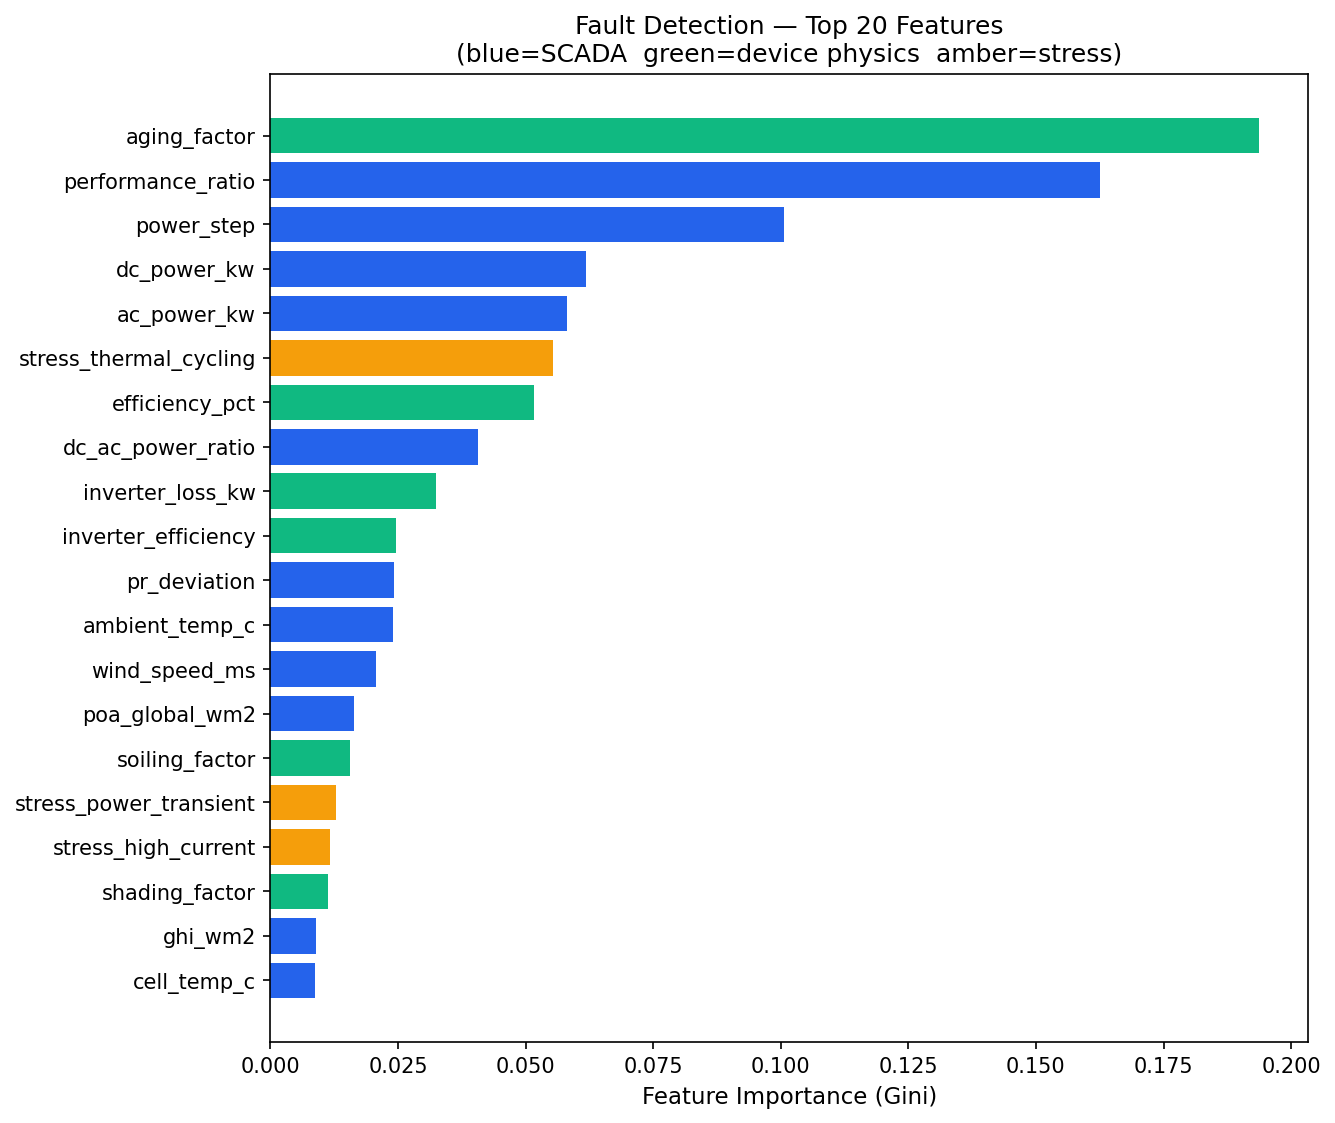

In [5]:
# Feature importance
plot_importance(
    model_det, feature_list,
    "Fault Detection",
    f"{OUTPUT_DIR}/importance_detection.png",
    scada_features=cfg.scada_features,
    device_features=cfg.device_features,
    top_n=20,
)
from IPython.display import Image
Image(f"{OUTPUT_DIR}/importance_detection.png")


## 5. Task 2 — Multi-class Fault Classification

In [6]:
model_cls, auc_cls, le_cls, class_names_cls = train_rf_from_registry(
    "Fault Classification",
    "fault_type",
    registry,
    feature_list,
    cfg,
    save_path=f"{OUTPUT_DIR}/rf_model_classification.pkl",
    save_deployment_path=f"{OUTPUT_DIR}/rf_deployment_classification.pkl",
)
if auc_cls:
    print(f"\nTest Weighted ROC AUC: {auc_cls:.4f}")



  RF FAULT CLASSIFICATION  (registry-based splits)
  Files: train=188  test=52
  Loading train files …
After daytime filter: 306,828 rows
After daytime filter: 306,687 rows
After daytime filter: 306,846 rows
After daytime filter: 306,809 rows
After daytime filter: 306,642 rows
After daytime filter: 306,826 rows
After daytime filter: 306,836 rows
After daytime filter: 306,679 rows
After daytime filter: 306,851 rows
After daytime filter: 306,861 rows
After daytime filter: 306,801 rows
After daytime filter: 306,969 rows
After daytime filter: 306,845 rows
After daytime filter: 306,723 rows
After daytime filter: 306,848 rows
After daytime filter: 306,834 rows
After daytime filter: 306,435 rows
After daytime filter: 306,787 rows
After daytime filter: 306,824 rows
After daytime filter: 306,965 rows
After daytime filter: 307,604 rows
After daytime filter: 307,815 rows
After daytime filter: 307,942 rows
After daytime filter: 308,000 rows
After daytime filter: 307,992 rows
After daytime filter:

  Saved importance_classification.png


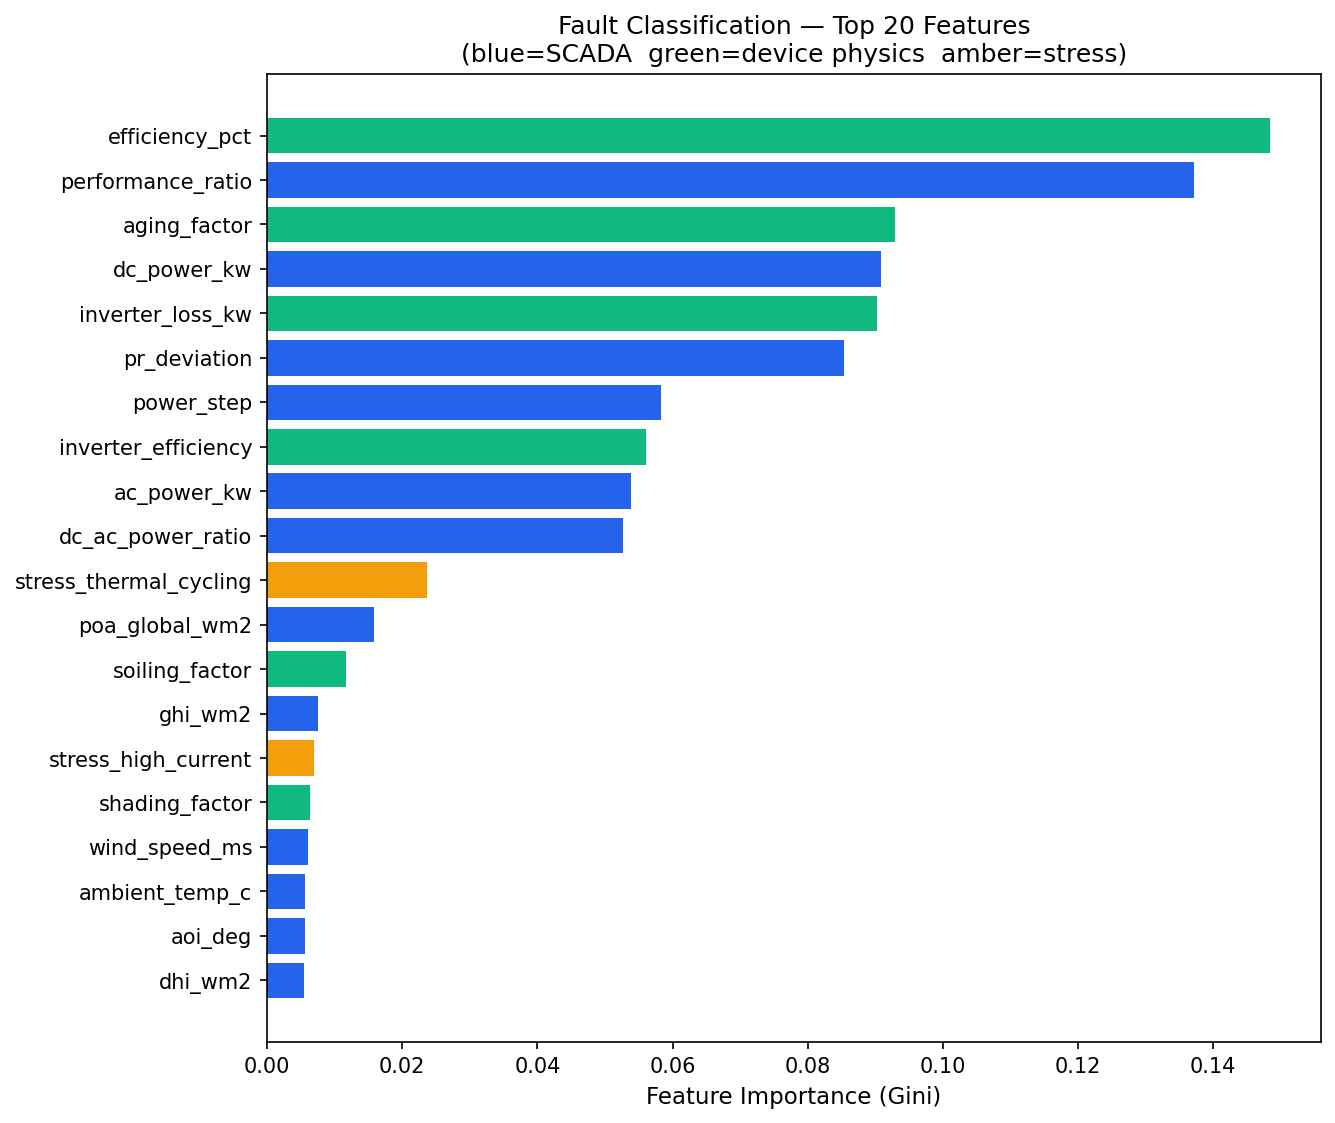

In [7]:
plot_importance(
    model_cls, feature_list,
    "Fault Classification",
    f"{OUTPUT_DIR}/importance_classification.png",
    scada_features=cfg.scada_features,
    device_features=cfg.device_features,
)
Image(f"{OUTPUT_DIR}/importance_classification.png")


## 6. Task 3 — Temporal Robustness

In [8]:
temporal_results = run_temporal_split(registry, feature_list, pathlib.Path(OUTPUT_DIR), cfg)
print("\nTemporal split results:")
for k, v in temporal_results.items():
    print(f"  {k}: {v:.4f}")



  TEMPORAL SPLIT (train years 1…N-1, test year N)
  Discovering sim_year per file …
  Only 1 year(s) in train/val — skipping.

Temporal split results:


## 7. Task 4 — Cross-Location Generalisation

In [9]:
# Requires data from multiple sites — skip gracefully if only one site
cross_results = run_cross_location(registry, feature_list, pathlib.Path(OUTPUT_DIR), cfg)
if cross_results:
    import pandas as pd
    display(pd.DataFrame(cross_results).set_index("test_location"))



  CROSS-LOCATION GENERALISATION (leave-one-site-out)
  Discovering location per file …
  Found 6 locations: 25.77_-80.19, 33.45_-112.07, 34.05_-118.24, 35.08_-106.65, 37.69_-97.34, 44.05_-123.1
  Fitting global LabelEncoder …

  test_loc = 25.77_-80.19 (Miami)
After daytime filter: 307,835 rows
After daytime filter: 307,790 rows
After daytime filter: 307,987 rows
After daytime filter: 307,415 rows
After daytime filter: 307,489 rows
After daytime filter: 306,832 rows
After daytime filter: 307,175 rows
After daytime filter: 302,072 rows
After daytime filter: 302,957 rows
After daytime filter: 299,811 rows
After daytime filter: 299,039 rows
After daytime filter: 298,908 rows
After daytime filter: 307,604 rows
After daytime filter: 307,815 rows
After daytime filter: 307,942 rows
After daytime filter: 308,046 rows
After daytime filter: 308,000 rows
After daytime filter: 307,992 rows
After daytime filter: 307,540 rows
After daytime filter: 308,216 rows
After daytime filter: 307,810 rows
Aft

,test_loc_id,detection_auc,classification_auc,accuracy
test_location,,,,
Miami,25.77_-80.19,0.818199,0.822460,0.461904
Phoenix,33.45_-112.07,0.865406,0.950526,0.776515
Los Angeles,34.05_-118.24,0.876485,0.951841,0.732721
Albuquerque,35.08_-106.65,0.824615,0.917535,0.664186
Wichita,37.69_-97.34,0.844706,0.934130,0.672739
Eugene,44.05_-123.1,0.817350,0.933383,0.722799


## 8. Task 5 — Feature Ablation

In [10]:
# Ablation uses the same registry file-level splits as all other models —
# no row-level train_test_split, no cross-run leakage.
ablation_results = run_feature_ablation(registry, pathlib.Path(OUTPUT_DIR), cfg)
import pandas as pd
display(pd.DataFrame(ablation_results))



  FEATURE ABLATION  (registry file-level splits)
  Loading train (200 files) …
After daytime filter: 306,529 rows
After daytime filter: 306,678 rows
After daytime filter: 306,917 rows
After daytime filter: 307,835 rows
After daytime filter: 307,987 rows
After daytime filter: 307,489 rows
After daytime filter: 306,832 rows
After daytime filter: 307,175 rows
After daytime filter: 302,957 rows
After daytime filter: 299,811 rows
After daytime filter: 299,039 rows
After daytime filter: 298,908 rows
After daytime filter: 306,828 rows
After daytime filter: 306,687 rows
After daytime filter: 306,846 rows
After daytime filter: 306,809 rows
After daytime filter: 306,642 rows
After daytime filter: 306,826 rows
After daytime filter: 306,836 rows
After daytime filter: 306,679 rows
After daytime filter: 306,851 rows
After daytime filter: 306,861 rows
After daytime filter: 306,801 rows
After daytime filter: 306,969 rows
After daytime filter: 306,845 rows
After daytime filter: 306,723 rows
After dayt

,feature_set,n_features,auc
0,SCADA only,19,0.856158
1,SCADA + stress (deployment),25,0.870483
2,SCADA + device physics,27,0.893366
3,Full (SCADA + physics + stress),33,0.896373


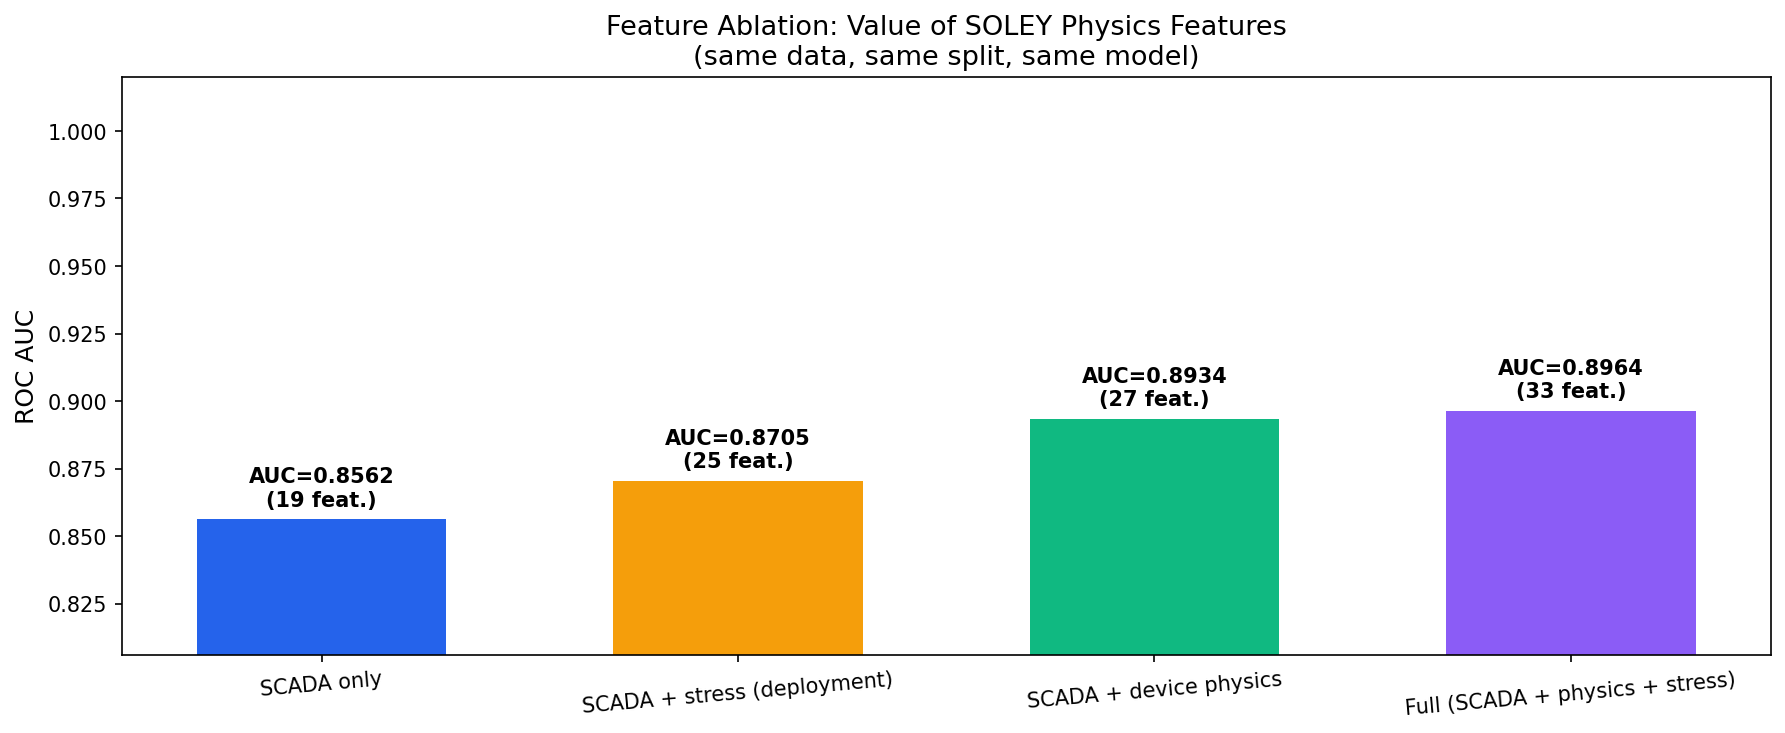

In [11]:
Image(f"{OUTPUT_DIR}/feature_ablation.png")


## 9. Results Summary

In [12]:
print("=" * 55)
print("RANDOM FOREST RESULTS SUMMARY")
print("=" * 55)
print(f"Detection  ROC AUC (registry test split): {auc_det:.4f}")
if auc_cls:
    print(f"Classification ROC AUC (registry test split): {auc_cls:.4f}")
for k, v in temporal_results.items():
    print(f"Temporal {k}:  {v:.4f}")
if cross_results:
    avg_d = np.nanmean([r['detection_auc'] for r in cross_results])
    avg_c = np.nanmean([r['classification_auc'] for r in cross_results])
    print(f"Cross-location avg Detection AUC:       {avg_d:.4f}")
    print(f"Cross-location avg Classification AUC: {avg_c:.4f}")
delta = ablation_results[-1]['auc'] - ablation_results[0]['auc']
print(f"Ablation delta (Full - SCADA only):  {delta:+.4f} AUC")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")


RANDOM FOREST RESULTS SUMMARY
Detection  ROC AUC (registry test split): 0.8965
Classification ROC AUC (registry test split): 0.9070
Cross-location avg Detection AUC:       0.8411
Cross-location avg Classification AUC: 0.9183
Ablation delta (Full - SCADA only):  +0.0402 AUC

All outputs saved to: outputs/random_forest
